# **Artemis II** : simulation numérique de la trajectoire

## Présentation

Les données fournies par le **JPL** donnent accès à la trajectoire suivie par le véhicule **Orion** dans le cadre de la mission **Artemis II**. On peut ainsi comparer cette trajectoire à celle obtenue par simulation numérique en appliquant les lois de Newton. La position et la vitesse initiale de cette simulation sont celles du véhicule **Orion** à une date initiale choisie.

Pour la simulation, on choisit le référentiel **ICRS** avec son origine placée au barycentre du système solaire. Les positions de la Terre, de la Lune et du Soleil sont donc données dans ce référentiel. On suppose que seuls ces astres influent sur l'accélération du véhicule. On vérifie ainsi ce que serait la trajectoire du véhicule  **sans aucun moyen de propulsion supplémentaire**. Par commodité, les résultats des simulations seront ensuite affichés dans le référentiel géocentrique écliptique.

## Descriptions et commentaires sur les essais menés

### Simulation juste après l'ITL (Injection Trans-Lunaire)

La date choisie pour fixer les valeurs initiales de position et de vitesse est le **3 avril 2026 à 00h00 UTC**, peu après qu'ait eu lieu la "grosse poussée" permettant le transit vers la Lune. La simulation se termine le **10 avril 2026 à 23h54 UTC**, car après cette date, les données sur la trajectoire d'Orion qui est alors tout près de la Terre, ne sont plus disponibles.

Après simulation numérique, on constate que le véhicule Orion sans moyen de propulsion aurait suivi une trajectoire très grossièrement comparable à la vraie trajectoire, avec cependant un écart d'environ **100000 km** à la date finale. Il est donc nécessaire de disposer d'un moyen de propulsion pour corriger la trajectoire.

### Simulation juste après la correction de trajectoire à proximité de la Lune

La date choisie pour fixer les valeurs initiales de position et de vitesse est le **6 avril 2026 à 03h30 UTC**, au moment où le véhicule s'approche de la Lune avant d'en faire le tour. Une correction a déjà été appliquée sous la forme d'un "delta V" d'environ 3 mètres par seconde.

Après simulation numérique, on obtient un bien meilleur suivi de la vraie trajectoire,  avec un écart d'environ **400 km** à la date finale.

### Simulation avec ajustement de la vitesse initiale

La date choisie pour fixer les valeurs initiales de position et de vitesse est le **3 avril 2026 à 00h00 UTC**, peu après l'injection trans-lunaire. On ajuste la vraie vitesse initiale du véhicule, de sorte que l'on suive aussi précisément que possible la vraie trajectoire jusqu'à la date finale du **10 avril 2026 à 23h54 UTC**. On réduit ainsi l'écart qui vaut alors **140 km** environ à la date finale.

On constate que le "delta V" qu'il aurait fallu appliquer est de l'ordre de **2,5 mètres par seconde** ! C'est l'ordre de grandeur des différentes corrections qui ont été appliquées durant la mission.


### Conclusion

Ces différentes situations simulées mettent en évidence le fait que la trajectoire est extrèmement sensible aux conditions initiales, notamment dès le début du transit vers la Lune. Il faut donc des moyens de propulsion pour réaliser des petites corrections ("delta V") tout au long de la mission. Il serait en effet illusoire de n'ajuster la vitesse qu'au début du transit, afin que l'ensemble du trajet s'effectue librement selon une trajectoire préétablie.

# Programme

In [1]:
import numpy as np
import pandas as pd
import requests as rq
import io
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def req_jpl_read(id='-125544', EPHEM_TYPE='VECTORS', VEC_TABLE='2', CENTER='500@399',
                 REF_PLANE='F', REF_SYSTEM='ICRF',
                 debut='2024-03-10 00:00:00', fin='2024-03-14 00:00:00', pas='1 m'):
    commande = 'https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND=\''+id +\
        '\'&OBJ_DATA=\'YES\'&MAKE_EPHEM=\'YES\'&EPHEM_TYPE=\''+EPHEM_TYPE +\
        '\'&VEC_TABLE=\''+VEC_TABLE+'\'&CSV_FORMAT=\'YES\'&CENTER=\''+CENTER +\
        '\'&REF_PLANE=\''+REF_PLANE+'\'&REF_SYSTEM=\''+REF_SYSTEM+'\'&START_TIME=\'' +\
        debut+'\'&STOP_TIME=\''+fin+'\'&STEP_SIZE=\''+pas+'\''

    print('Requête API JPL')
    print(commande)
    rep = rq.get(commande)
    # récupération et traitement du contenu en retour de la requête
    f = io.StringIO(rep.content.decode())
    lines = f.readlines()
    for line in lines:
        if line.find('$$SOE') != -1:
            debut = lines.index(line)
        if line.find('$$EOE') != -1:
            nlignes = lines.index(line)-debut-1
    f.close()
    # liste des lignes à ne pas prendre en compte
    skip = [n for n in range(0, debut-2)]
    skip.append(debut-1), skip.append(debut)
    # lecture du fichier de données
    f = io.StringIO(rep.content.decode())
    df = pd.read_csv(f, skiprows=skip, nrows=nlignes)
    f.close()
    # élimination de la dernière colonne qui est vide
    df = df.drop(df.columns[-1], axis=1)
    # format datetime pour les dates (en colonne 1)
    dates = pd.to_datetime(df.iloc[:, 1], format=' A.D. %Y-%b-%d %H:%M:%S.%f')
    df = df.drop(df.columns[1], axis=1)
    df.insert(1, 'DATES', dates)
    # noms des colonnes sans espace
    noms_col = [df.columns.values[n].strip()
                for n in range(len(df.columns.values))]
    df.columns = noms_col
    return df


def trace3D_traj(Astre, Sat1, Sat2, XYZ1, XYZ2, dates1, dates2):
    plt.figure(figsize=(10, 7))
    ax = plt.axes(projection='3d')
    ax.scatter(0, 0, 0, c='g', s=5, label=Astre)
    ax.scatter(XYZ1[0, 0], XYZ1[0, 1], XYZ1[0, 2],
               c='b', s=10, marker=',', label='début : '+dates1[0].strftime('%d/%m/%Y à %H:%M'))
    ax.scatter(XYZ1[-1, 0], XYZ1[-1, 1], XYZ1[-1, 2],
               c='k', s=10, marker=',', label='fin : '+dates1[len(dates1)-1].strftime('%d/%m/%Y à %H:%M'))
    ax.scatter(XYZ2[0, 0], XYZ2[0, 1], XYZ2[0, 2],
               c='b', s=10, marker='^', label='début : '+dates2[0].strftime('%d/%m/%Y à %H:%M'))
    ax.scatter(XYZ2[-1, 0], XYZ2[-1, 1], XYZ2[-1, 2],
               c='k', s=10, marker='^', label='fin : '+dates2[len(dates2)-1].strftime('%d/%m/%Y à %H:%M'))
    ax.plot3D(XYZ1[:, 0], XYZ1[:, 1], XYZ1[:, 2], 'b', label=Sat1, lw=0.5)
    ax.plot3D(XYZ2[:, 0], XYZ2[:, 1], XYZ2[:, 2], 'r', label=Sat2, lw=0.5)
    ax.set_title('Trajectoire '+Sat1+' '+Sat2+' (origine '+Astre+')')
    ax.set_xlabel('X (en km)')
    ax.set_ylabel('Y (en km)')
    ax.set_zlabel('Z (en km)')
    ax.axis('equal')
    ax.legend()


def trace2D_distance(lab1, lab2, XYZ1, XYZ2, dates1, dates2):
    _, ax = plt.subplots(figsize=(8, 6))
    plt.xticks(rotation=30, horizontalalignment='right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y %H:%M'))
    ax.plot(dates1, np.sqrt(XYZ1[:, 0]**2 +
                            XYZ1[:, 1]**2+XYZ1[:, 2]**2), 'b', lw=1, label=lab1)
    if lab2 != '':
        ax.plot(dates2, np.sqrt(XYZ2[:, 0]**2 +
                                XYZ2[:, 1]**2+XYZ2[:, 2]**2), 'r', lw=1, label=lab2)
    ax.set_title('Distances')
    ax.set_xlabel('temps (dates)')
    ax.set_ylabel('distance (en km)')
    ax.grid('on')
    ax.legend()

In [2]:
def requ_et_sauve(nom_csv, id, ephem_type, vec_table, center,
                  ref_plane, ref_system, debut, fin, pas):
    try:
        df = pd.read_csv(nom_csv)
        print('Lecture du fichier '+nom_csv)
    except FileNotFoundError:
        print('Requête initiale pour créer le fichier '+nom_csv)
        df = req_jpl_read(id, ephem_type, vec_table, center,
                          ref_plane, ref_system, debut, fin, pas)
        df.to_csv(nom_csv, index=False)

    data = df.loc[:, ['X', 'Y', 'Z', 'VX', 'VY', 'VZ']].values
    dates = pd.to_datetime(df.loc[:, 'DATES'])
    pos = data[:, 0:3]
    vit = data[:, 3:6]
    return dates, pos, vit

# Les paramètres gravitationnels standards

| Nom | mu | units | id |
|:-:|:-|:-:|:-:|
|Soleil|132712440041.279419|km^3 s^-2|10|
|Mercure|22031.868551|km^3 s^-2|1|
|Venus|324858.592000|km^3 s^-2|2|
|Terre|398600.435507|km^3 s^-2|399|
|Lune|4902.800118|km^3 s^-2|301|
|Mars|42828.375816|km^3 s^-2|4|
|Jupiter|126712764.100000|km^3 s^-2|5|
|Saturne|37940584.841800|km^3 s^-2|6|
|Uranus|5794556.400000|km^3 s^-2|7|
|Neptune|6836527.100580|km^3 s^-2|8|

# La méthode d'intégration numérique

In [3]:
# Méthode rk8
# (Runge-Kutta d'ordre 8)


def rk8(f, t, y0):
    y = np.zeros((len(t), len(y0)))
    k1 = np.zeros(len(y0))
    k2 = np.copy(k1)
    k3 = np.copy(k1)
    k4 = np.copy(k1)
    k5 = np.copy(k1)
    k6 = np.zeros(len(y0))
    k7 = np.copy(k1)
    k8 = np.copy(k1)
    k9 = np.copy(k1)
    k10 = np.copy(k1)
    y[0, :] = y0[:]
    for n in np.arange(1, len(t)):
        yprec = y[n-1]
        tprec = t[n-1]
        h = t[n]-tprec
        k1[:] = f(tprec, yprec)
        k2[:] = f(tprec+h*(4/27), yprec+(h*4/27)*k1)
        k3[:] = f(tprec+h*(2/9), yprec+(h/18)*(k1+3*k2))
        k4[:] = f(tprec+h*(1/3), yprec+(h/12)*(k1+3*k3))
        k5[:] = f(tprec+h*(1/2), yprec+(h/8)*(k1+3*k4))
        k6[:] = f(tprec+h*(2/3), yprec+(h/54)*(13*k1-27*k3+42*k4+8*k5))
        k7[:] = f(tprec+h*(1/6), yprec+(h/4320) *
                  (389*k1-54*k3+966*k4-824*k5+243*k6))
        k8[:] = f(tprec+h, yprec+(h/20) *
                  (-231*k1+81*k3-1164*k4+656*k5-122*k6+800*k7))
        k9[:] = f(tprec+h*(5/6), yprec+(h/288) *
                  (-127*k1+18*k3-678*k4+456*k5-9*k6+576*k7+4*k8))
        k10[:] = f(tprec+h, yprec+(h/820)*(1481*k1-81*k3 +
                   7104*k4-3376*k5+72*k6-5040*k7-60*k8+720*k9))
        y[n, :] = yprec+(h/840)*(41*k1+27*k4+272*k5+27*k6+216*k7+216*k9+41*k10)
    return t, y


def f(t, y, mu, pos):
    N = len(mu)
    yp = np.zeros(6)
    P = y[0:3]
    yp[0:3] = y[3:6]
    for n in range(N):
        Pn = pos[n](t)
        yp[3:6] = yp[3:6]-mu[n]*(P-Pn)/np.sqrt(sum((P-Pn)**2))**3
    return yp

In [4]:
from scipy.interpolate import CubicSpline

# Simulation juste après l'ITL (Injection Trans-Lunaire)

Lecture du fichier artemis2.csv
Lecture du fichier lune.csv
Lecture du fichier terre.csv
Lecture du fichier soleil.csv


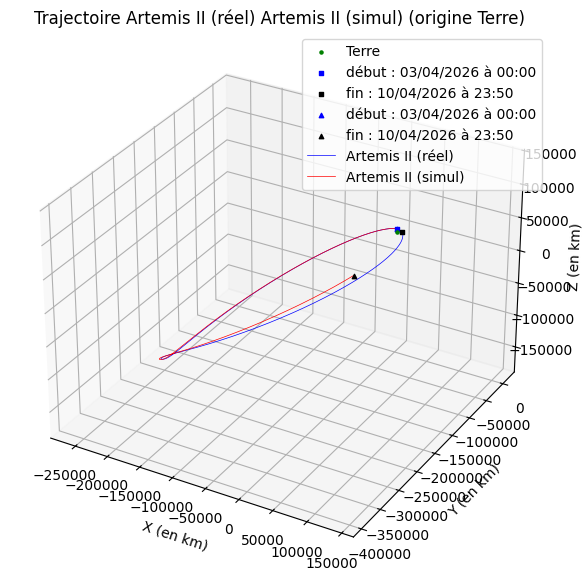

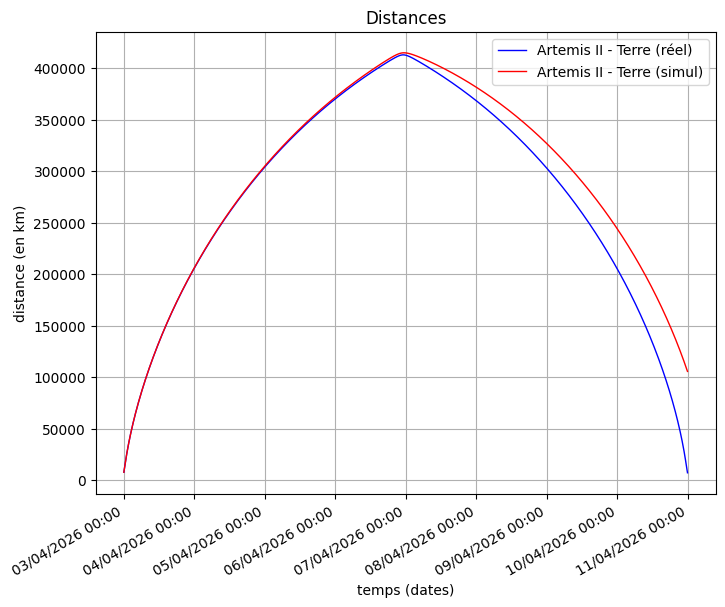

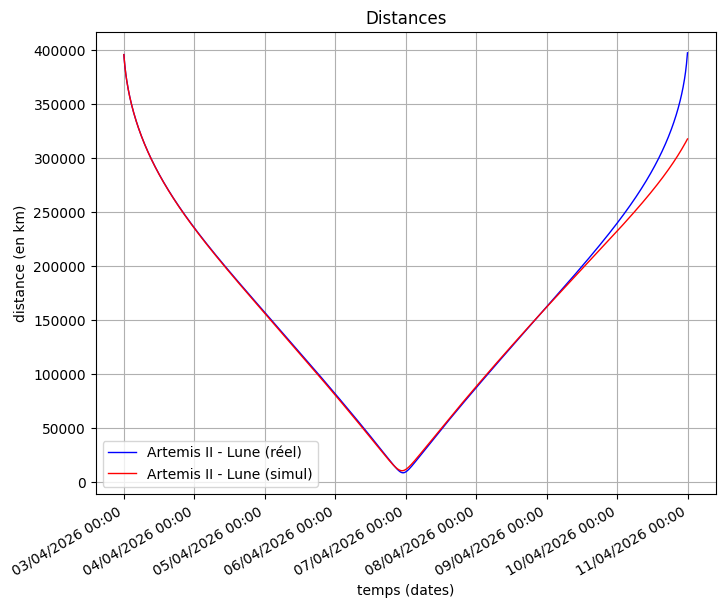

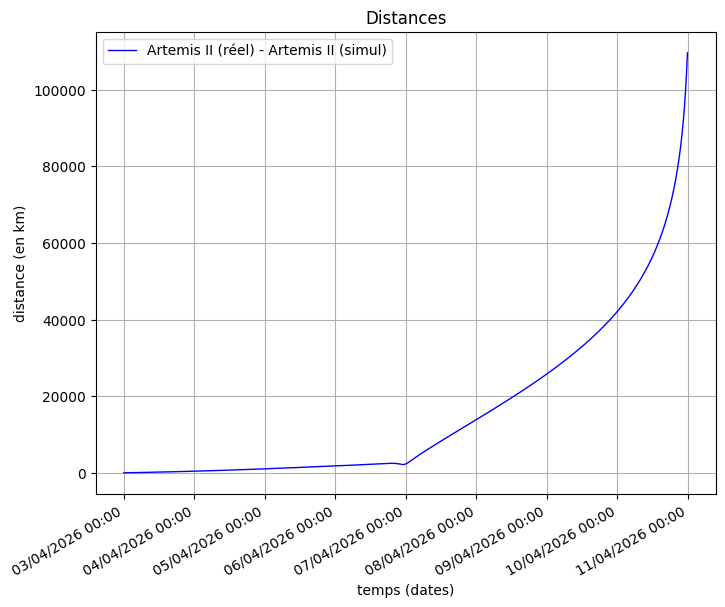

In [5]:
ephem_type = 'VECTORS'
vec_table = '2'
center = '@SSB'
ref_plane = 'E'
ref_system = 'ICRF'
debut = '2026-04-03%2000:00'
# debut = '2026-04-06%2003:30'
fin = '2026-04-10%2023:54'
pas = '10m'

artemis2_dates, artemis2_pos, artemis2_vit = requ_et_sauve('artemis2.csv', 'Artemis%20II', ephem_type, vec_table, center,
                                                           ref_plane, ref_system, debut, fin, pas)
lune_dates, lune_pos, lune_vit = requ_et_sauve('lune.csv', '301', ephem_type, vec_table, center,
                                               ref_plane, ref_system, debut, fin, pas)
terre_dates, terre_pos, terre_vit = requ_et_sauve('terre.csv', '399', ephem_type, vec_table, center,
                                                  ref_plane, ref_system, debut, fin, pas)
soleil_dates, soleil_pos, soleil_vit = requ_et_sauve('soleil.csv', 'sun', ephem_type, vec_table, center,
                                                     ref_plane, ref_system, debut, fin, pas)
temps = [(artemis2_dates[n]-artemis2_dates[0]).total_seconds()
         for n in range(len(artemis2_dates))]

terre_int = CubicSpline(temps, terre_pos)
lune_int = CubicSpline(temps, lune_pos)
soleil_int = CubicSpline(temps, soleil_pos)

y0 = np.concatenate((artemis2_pos[0, :], artemis2_vit[0, :]))
mu = [398600.435507, 4902.800118, 132712440041.279419]
pos = [terre_int, lune_int, soleil_int]
_, y = rk8(lambda t, y: f(t, y, mu, pos), temps, y0)
trace3D_traj('Terre', 'Artemis II (réel)', 'Artemis II (simul)', artemis2_pos - terre_pos,
             y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Terre (réel)', 'Artemis II - Terre (simul)', artemis2_pos - terre_pos,
                 y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Lune (réel)', 'Artemis II - Lune (simul)', artemis2_pos - lune_pos,
                 y[:, 0:3] - lune_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II (réel) - Artemis II (simul)', '', artemis2_pos - y[:, 0:3],
                 [], artemis2_dates, [])

# Simulation juste après la correction de trajectoire à proximité de la Lune

Lecture du fichier artemis2_bis.csv
Lecture du fichier lune_bis.csv
Lecture du fichier terre_bis.csv
Lecture du fichier soleil_bis.csv


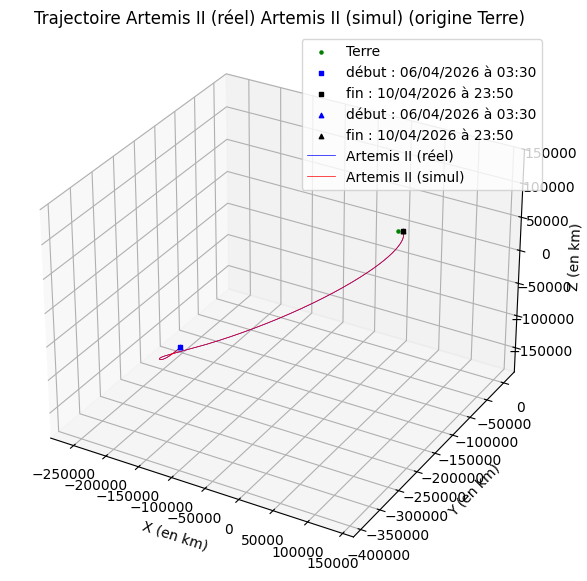

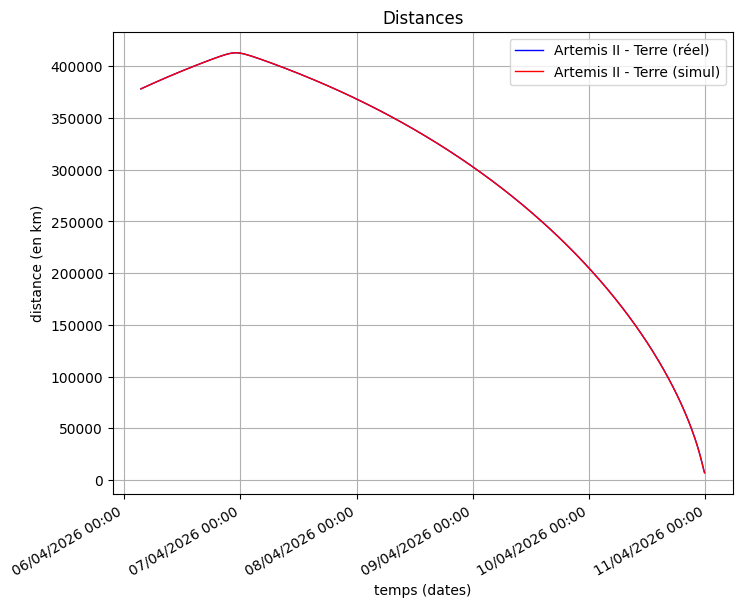

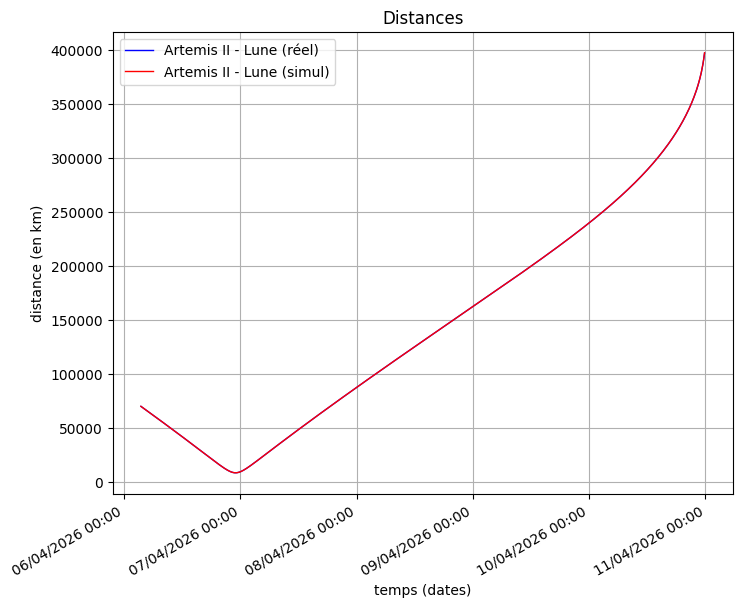

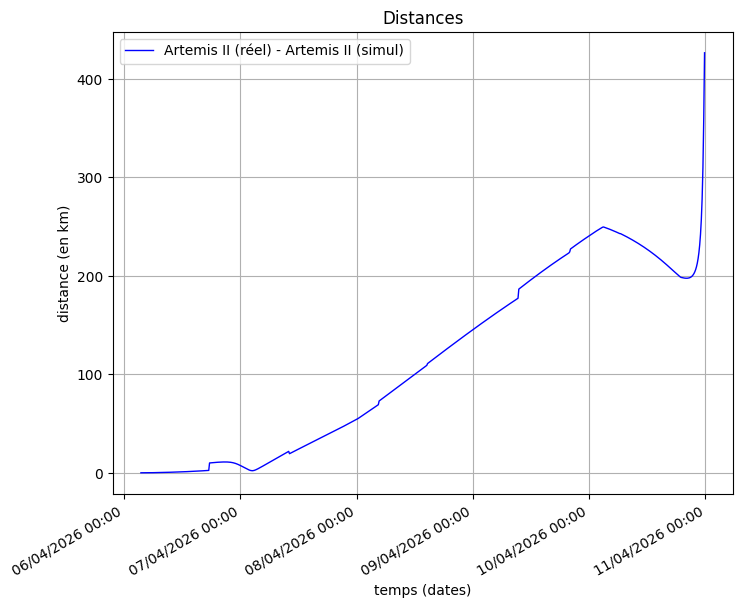

In [6]:
ephem_type = 'VECTORS'
vec_table = '2'
center = '@SSB'
ref_plane = 'E'
ref_system = 'ICRF'
# debut = '2026-04-03%2000:00'
debut = '2026-04-06%2003:30'
fin = '2026-04-10%2023:54'
pas = '10m'

artemis2_dates, artemis2_pos, artemis2_vit = requ_et_sauve('artemis2_bis.csv', 'Artemis%20II', ephem_type, vec_table, center,
                                                           ref_plane, ref_system, debut, fin, pas)
lune_dates, lune_pos, lune_vit = requ_et_sauve('lune_bis.csv', '301', ephem_type, vec_table, center,
                                               ref_plane, ref_system, debut, fin, pas)
terre_dates, terre_pos, terre_vit = requ_et_sauve('terre_bis.csv', '399', ephem_type, vec_table, center,
                                                  ref_plane, ref_system, debut, fin, pas)
soleil_dates, soleil_pos, soleil_vit = requ_et_sauve('soleil_bis.csv', 'sun', ephem_type, vec_table, center,
                                                     ref_plane, ref_system, debut, fin, pas)
temps = [(artemis2_dates[n]-artemis2_dates[0]).total_seconds()
         for n in range(len(artemis2_dates))]

terre_int = CubicSpline(temps, terre_pos)
lune_int = CubicSpline(temps, lune_pos)
soleil_int = CubicSpline(temps, soleil_pos)

y0 = np.concatenate((artemis2_pos[0, :], artemis2_vit[0, :]))
mu = [398600.435507, 4902.800118, 132712440041.279419]
pos = [terre_int, lune_int, soleil_int]
_, y = rk8(lambda t, y: f(t, y, mu, pos), temps, y0)
trace3D_traj('Terre', 'Artemis II (réel)', 'Artemis II (simul)', artemis2_pos - terre_pos,
             y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Terre (réel)', 'Artemis II - Terre (simul)', artemis2_pos - terre_pos,
                 y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Lune (réel)', 'Artemis II - Lune (simul)', artemis2_pos - lune_pos,
                 y[:, 0:3] - lune_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II (réel) - Artemis II (simul)', '', artemis2_pos - y[:, 0:3],
                 [], artemis2_dates, [])

# Simulation avec ajustement de la vitesse initiale

Lecture du fichier artemis2.csv
Lecture du fichier lune.csv
Lecture du fichier terre.csv
Lecture du fichier soleil.csv
coordonnées vitesse initiale (km/s) :  [ -3.76014292 -31.00590138  -0.33334755]
coordonnées vitesse ajustée (km/s) :  [ -3.75881322 -31.0068765   -0.33521418]
norme de la différence entre vitesse ajustée et vitesse initiale (m/s) :  2.4906311214643297


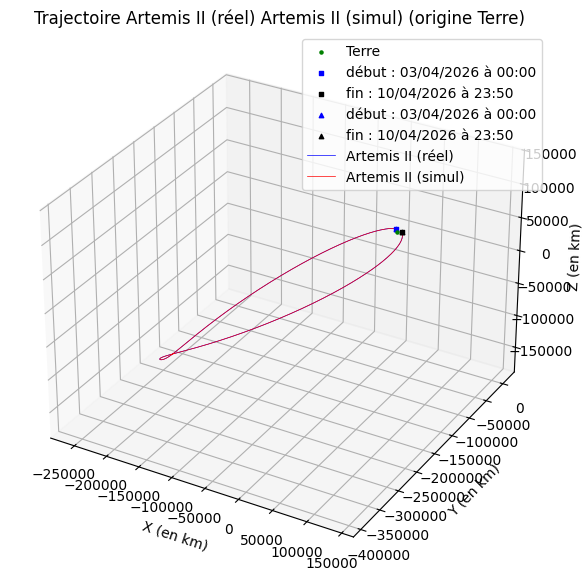

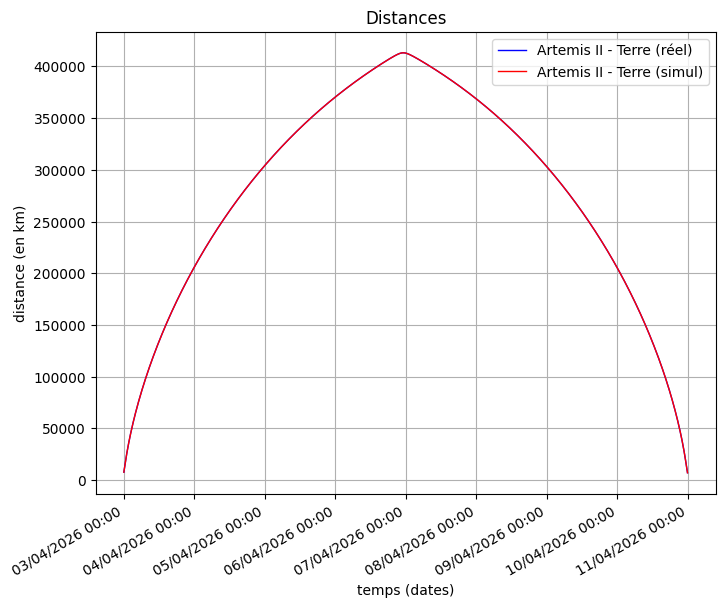

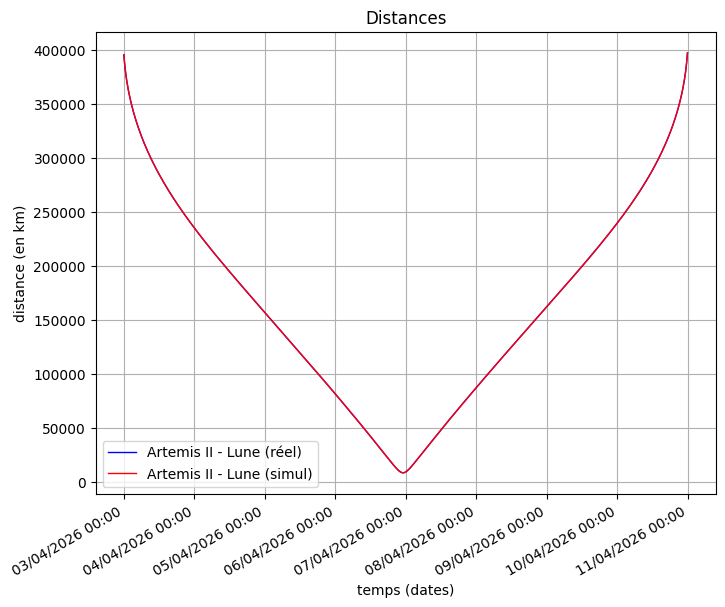

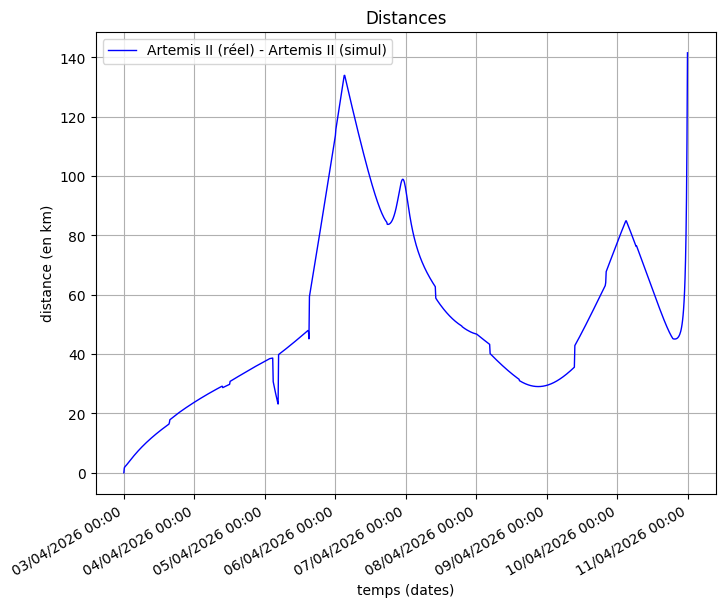

In [7]:
from scipy.optimize import least_squares
from numpy.linalg import norm


def recherche(params):
    y0[3:6] = params
    _, y = rk8(lambda t, y: f(t, y, mu, pos), temps, y0)
    ecart = artemis2_pos - y[:, 0:3]
    return ecart.flatten()


ephem_type = 'VECTORS'
vec_table = '2'
center = '@SSB'
ref_plane = 'E'
ref_system = 'ICRF'
debut = '2026-04-03%2000:00'
# debut = '2026-04-06%2003:30'
fin = '2026-04-10%2023:54'
pas = '10m'

artemis2_dates, artemis2_pos, artemis2_vit = requ_et_sauve('artemis2.csv', 'Artemis%20II', ephem_type, vec_table, center,
                                                           ref_plane, ref_system, debut, fin, pas)
lune_dates, lune_pos, lune_vit = requ_et_sauve('lune.csv', '301', ephem_type, vec_table, center,
                                               ref_plane, ref_system, debut, fin, pas)
terre_dates, terre_pos, terre_vit = requ_et_sauve('terre.csv', '399', ephem_type, vec_table, center,
                                                  ref_plane, ref_system, debut, fin, pas)
soleil_dates, soleil_pos, soleil_vit = requ_et_sauve('soleil.csv', 'sun', ephem_type, vec_table, center,
                                                     ref_plane, ref_system, debut, fin, pas)
temps = [(artemis2_dates[n]-artemis2_dates[0]).total_seconds()
         for n in range(len(artemis2_dates))]

terre_int = CubicSpline(temps, terre_pos)
lune_int = CubicSpline(temps, lune_pos)
soleil_int = CubicSpline(temps, soleil_pos)

y0 = np.concatenate((artemis2_pos[0, :], artemis2_vit[0, :]))
mu = [398600.435507, 4902.800118, 132712440041.279419]
pos = [terre_int, lune_int, soleil_int]

result = least_squares(recherche, artemis2_vit[0, :])
y0 = np.concatenate((artemis2_pos[0, :], result.x))
_, y = rk8(lambda t, y: f(t, y, mu, pos), temps, y0)

print('coordonnées vitesse initiale (km/s) : ', artemis2_vit[0, :])
print('coordonnées vitesse ajustée (km/s) : ', y0[3:6])
print('norme de la différence entre vitesse ajustée et vitesse initiale (m/s) : ',
      1000.0*norm(y0[3:6] - artemis2_vit[0, :]))

trace3D_traj('Terre', 'Artemis II (réel)', 'Artemis II (simul)', artemis2_pos - terre_pos,
             y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Terre (réel)', 'Artemis II - Terre (simul)', artemis2_pos - terre_pos,
                 y[:, 0:3] - terre_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II - Lune (réel)', 'Artemis II - Lune (simul)', artemis2_pos - lune_pos,
                 y[:, 0:3] - lune_pos, artemis2_dates, lune_dates)
trace2D_distance('Artemis II (réel) - Artemis II (simul)', '', artemis2_pos - y[:, 0:3],
                 [], artemis2_dates, [])